In [1]:
import numpy as np
import torch
import matplotlib.pyplot as pyplot

In [2]:
from czt1d import ChirpZTransform1D

In [3]:
ftype = torch.float64
ctype = torch.complex128

In [4]:
npts = 128
mpts = 256
n = torch.arange(npts, dtype=ftype)
k = torch.arange(mpts, dtype=ftype)

dx = 0.02
x = n * dx

f0 = 3.0
f1 = 4.0
y = torch.sin(2*np.pi*f0*x) * torch.exp(-f0*x/2) + 0.2*torch.sin(2*np.pi*f1*x)

In [5]:
f_start = 2.0
f_stop = 6.0

In [6]:
f = torch.fft.fftshift(torch.fft.fftfreq(npts, d=dx))
yft = torch.fft.fftshift(torch.fft.fft(y))

In [7]:
czt = ChirpZTransform1D(npts, mpts, dx, f_start, f_stop)
czt = czt.eval()

In [8]:
with torch.no_grad():
    out = czt(y)

In [9]:
czt.conv_length

512

In [10]:
czt.freq

tensor([2.0000, 2.0157, 2.0314, 2.0471, 2.0627, 2.0784, 2.0941, 2.1098, 2.1255,
        2.1412, 2.1569, 2.1725, 2.1882, 2.2039, 2.2196, 2.2353, 2.2510, 2.2667,
        2.2824, 2.2980, 2.3137, 2.3294, 2.3451, 2.3608, 2.3765, 2.3922, 2.4078,
        2.4235, 2.4392, 2.4549, 2.4706, 2.4863, 2.5020, 2.5176, 2.5333, 2.5490,
        2.5647, 2.5804, 2.5961, 2.6118, 2.6275, 2.6431, 2.6588, 2.6745, 2.6902,
        2.7059, 2.7216, 2.7373, 2.7529, 2.7686, 2.7843, 2.8000, 2.8157, 2.8314,
        2.8471, 2.8627, 2.8784, 2.8941, 2.9098, 2.9255, 2.9412, 2.9569, 2.9725,
        2.9882, 3.0039, 3.0196, 3.0353, 3.0510, 3.0667, 3.0824, 3.0980, 3.1137,
        3.1294, 3.1451, 3.1608, 3.1765, 3.1922, 3.2078, 3.2235, 3.2392, 3.2549,
        3.2706, 3.2863, 3.3020, 3.3176, 3.3333, 3.3490, 3.3647, 3.3804, 3.3961,
        3.4118, 3.4275, 3.4431, 3.4588, 3.4745, 3.4902, 3.5059, 3.5216, 3.5373,
        3.5529, 3.5686, 3.5843, 3.6000, 3.6157, 3.6314, 3.6471, 3.6627, 3.6784,
        3.6941, 3.7098, 3.7255, 3.7412, 

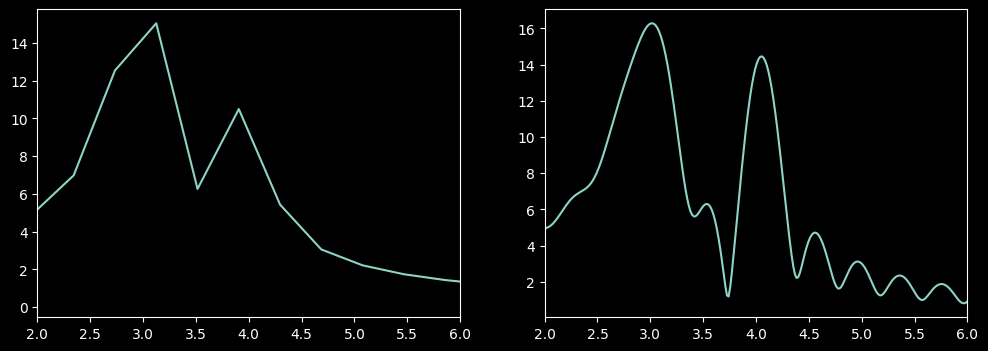

In [11]:
fig, axarr = pyplot.subplots(1, 2, figsize=(12, 4))
ax1, ax2 = axarr
ax1.plot(f, np.abs(yft))
ax2.plot(czt.freq.numpy(), np.abs(out.numpy()))

for ax in axarr:
    ax.set_xlim(f_start, f_stop)

In [12]:
import timeit

In [14]:
%timeit czt(y)

14.3 μs ± 63.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
